# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        l = X.shape[0]
        return (1 / l) * np.sum((X @ w - y) ** 2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        grad = (2 / l) * X.T @ (X @ w - y)
        return grad

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w = w_init.copy()
    history = []

    for i in range(n_iterations):
        grad = loss.calc_grad(X, y, w)
        w = w - lr * grad
        history.append(w.copy())

    return history

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.2625821435192
0.8670644395649493


In [8]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

lr = 0.0001
final loss: 169.8310869359105


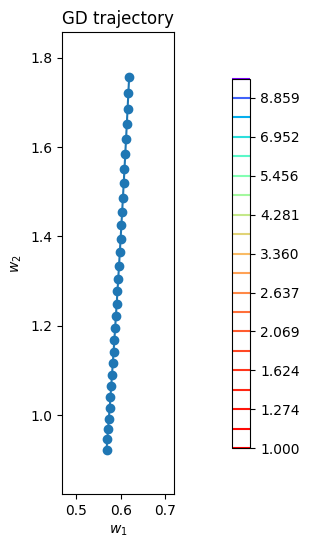

lr = 0.001
final loss: 6.056084036763843


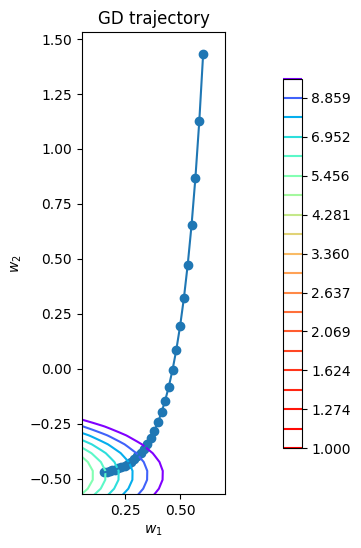

lr = 0.01
final loss: 0.8676452384843072


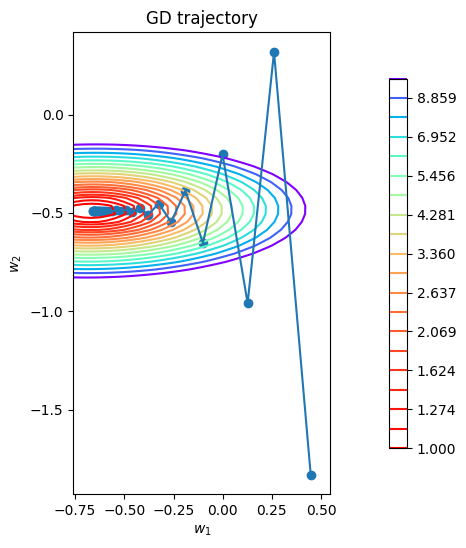

lr = 0.05
final loss: 1.5839013830767536e+53


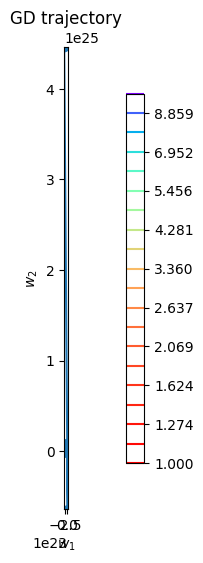

lr = 0.1
final loss: 1.1678319324839791e+73


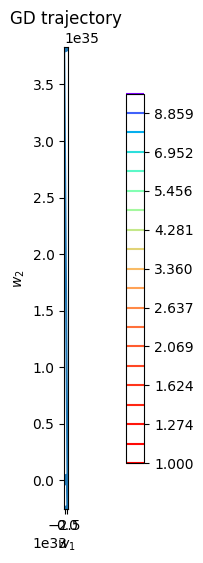

In [9]:
lrs = [0.0001, 0.001, 0.01, 0.05, 0.1]

for lr in lrs:
    print(f"lr = {lr}")
    history = gradient_descent(
        w_init=w_init,
        X=X,
        y=y,
        loss=loss,
        lr=lr,
        n_iterations=30
    )
    
    print("final loss:", loss.calc_loss(X, y, history[-1]))
    plot_gd(history, X, y, loss)

Как можно увидеть, на картинках при маленьком значении lr (0.0001) градиентный спуск идёт стабильно, но очень медленно, так как длина шага слишком маленькая. При умеренных значениях lr (0.001 и 0.01) спуск работает быстрее и траектория достаточно быстро приходит в область минимума функции потерь. Когда же слишком большом lr (0.05 и 0.1) алгоритм начинает делать слишком большие шаги, может перескакивать через минимум. Видим закономерность, что чем меньше lr, тем медленнее обучение, но тем стабильнее спуск, чем больше lr, тем быстрее шаги, но они могут колебаться или расходиться. Лучше всего выбирать промежуточные lr, когда спуск и быстрый, и устойчивый. Таким образом, параметр lr отвечает за баланс между скоростью сходимости и устойчивостью алгоритма. 

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [10]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w = w_init.copy()
    history = []

    for i in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        grad = loss.calc_grad(X_batch, y_batch, w)
        w = w - lr * grad
        history.append(w.copy())

    return history

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

lr = 0.0001, batch_size = 1
final loss: 191.45625220328972


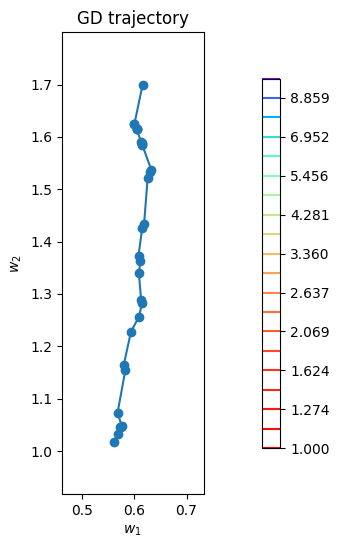

lr = 0.0001, batch_size = 5
final loss: 188.2975447803213


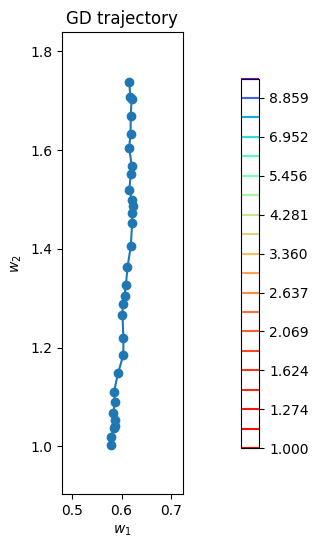

lr = 0.0001, batch_size = 20
final loss: 168.91360308691898


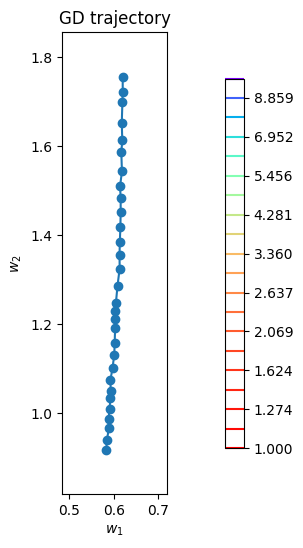

lr = 0.0001, batch_size = 300
final loss: 169.83108693591043


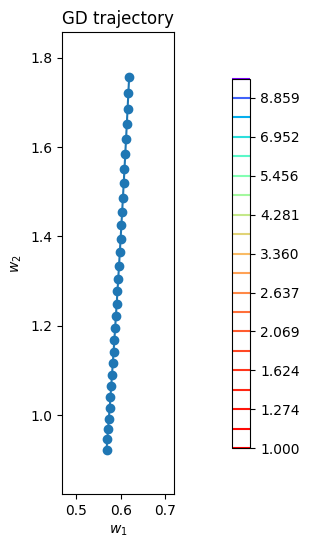

lr = 0.001, batch_size = 1
final loss: 7.697953088376808


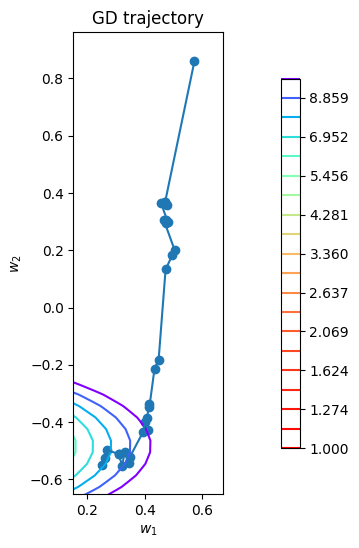

lr = 0.001, batch_size = 5
final loss: 7.094695643380502


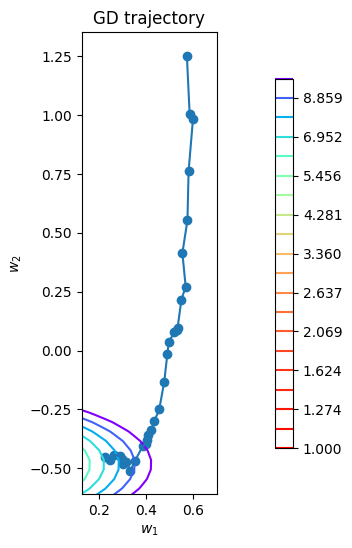

lr = 0.001, batch_size = 20
final loss: 6.638511535974179


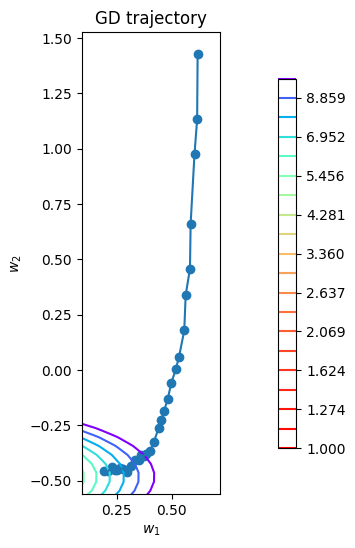

lr = 0.001, batch_size = 300
final loss: 6.056084036763843


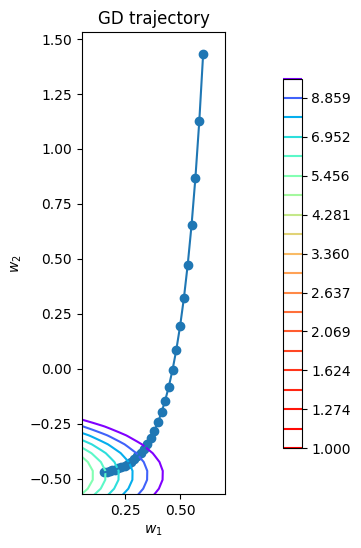

lr = 0.01, batch_size = 1
final loss: 314.8656446992112


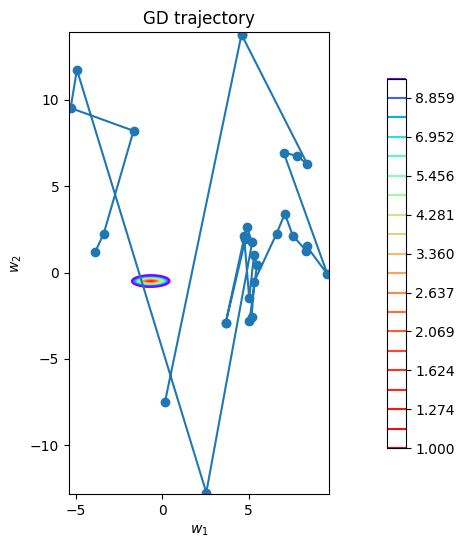

lr = 0.01, batch_size = 5
final loss: 1.2379644389128865


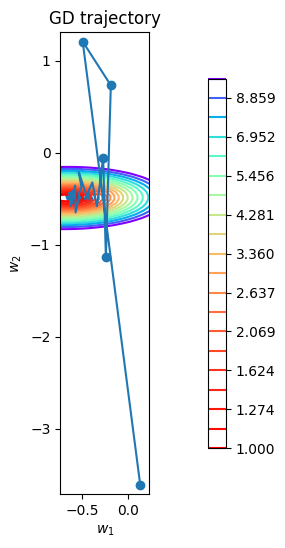

lr = 0.01, batch_size = 20
final loss: 1.1563318969282914


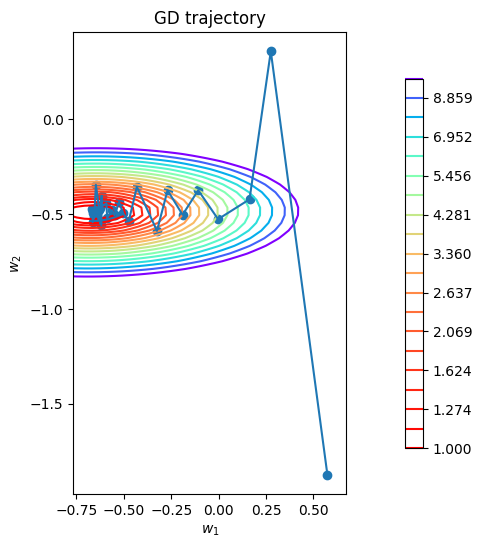

lr = 0.01, batch_size = 300
final loss: 0.8676452384843074


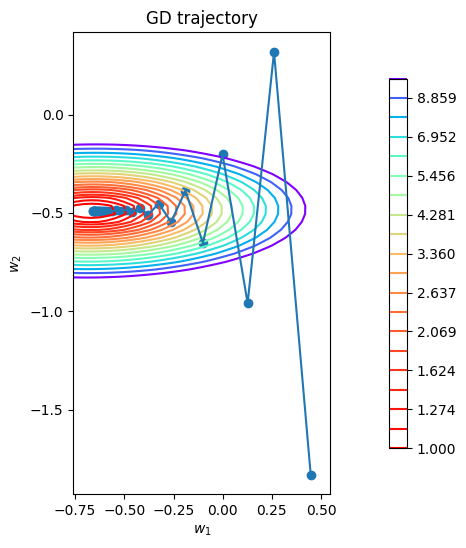

lr = 0.05, batch_size = 1
final loss: 1.8846049113231564e+28


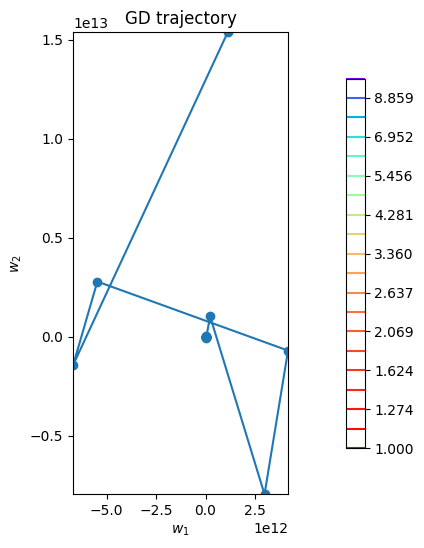

lr = 0.05, batch_size = 5
final loss: 3.982070853206558e+44


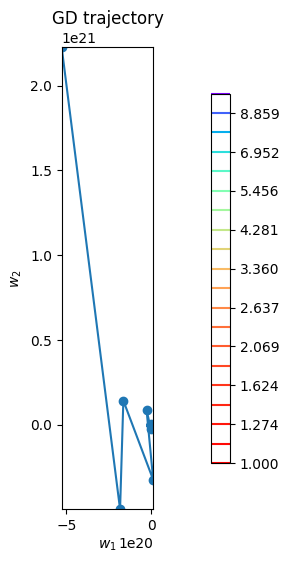

lr = 0.05, batch_size = 20
final loss: 1.4010450877860056e+53


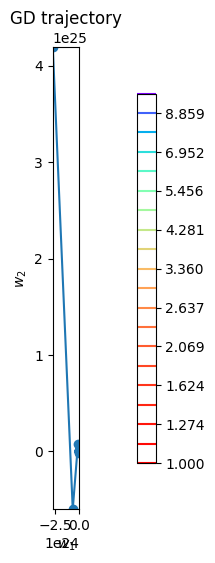

lr = 0.05, batch_size = 300
final loss: 1.5839013830767602e+53


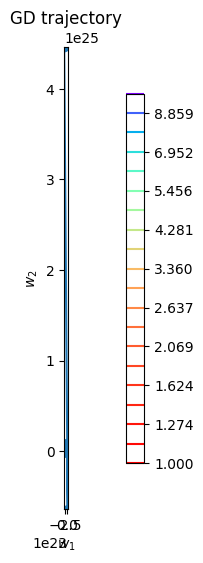

In [11]:
lrs = [0.0001, 0.001, 0.01, 0.05]
batch_sizes = [1, 5, 20, 300]

for lr in lrs:
    for batch_size in batch_sizes:
        np.random.seed(42) 

        print(f"lr = {lr}, batch_size = {batch_size}")

        history = stochastic_gradient_descent(
            w_init=w_init,
            X=X,
            y=y,
            loss=loss,
            lr=lr,
            batch_size=batch_size,
            n_iterations=30
        )

        print("final loss:", loss.calc_loss(X, y, history[-1]))
        plot_gd(history, X, y, loss)

Параметр lr отвечает за размер шага при обновлении весов, и если lr слишком маленький, то стохастический градиентный спуск движется к минимуму очень медленно. Если же lr больше, то сходимость сначала может быть быстрее, но при слишком больших шагах траектория начинает колебаться и может перепрыгивать минимум. 
Параметр batch_size отвечает за размер случайной подвыборки, по которой считается градиент на каждом шаге, при маленьком batch_size траектория получается шумной и ломаной, потому что градиент оценивается по небольшому числу объектов; а при большом batch_size траектория становится более гладкой, стабильной, потому что градиент считается точнее.
Стохастический градиентный спуск отличается от обычного тем, что в обычном градиент считается по всей выборке, а в стохастическом по случайному батчу, поэтому стохастический работает шумнее, но один его шаг вычисляется быстрее.
Когда маленький batch_size, например, 1, получаем очень шумное поведение, и шаги сильно зависят от случайно выбранного объекта. А при больших batch_size поведение становится всё ближе к обычному градиентному спуску. Если же batch_size максимален, 300, то градиент считается по всей выборке, поэтому это уже практически обычный градиентный спуск.

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [12]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w = w_init.copy()
    history = []
    s0 = 1

    for t in range(n_iterations):
        eta_t = lr * (s0 / (s0 + t)) ** p
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        grad = loss.calc_grad(X_batch, y_batch, w)
        w = w - eta_t * grad
        history.append(w.copy())

    return history

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

p = 0.1
final loss: 0.8761557451331718


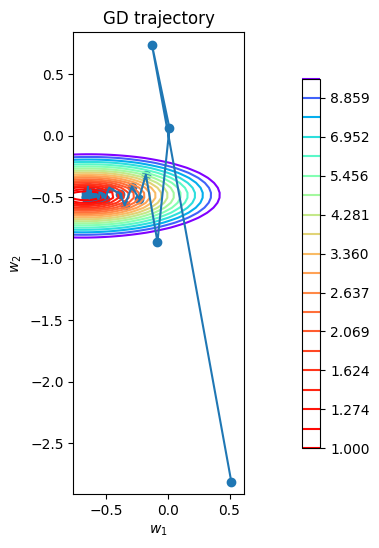

p = 0.3
final loss: 0.9243760082677875


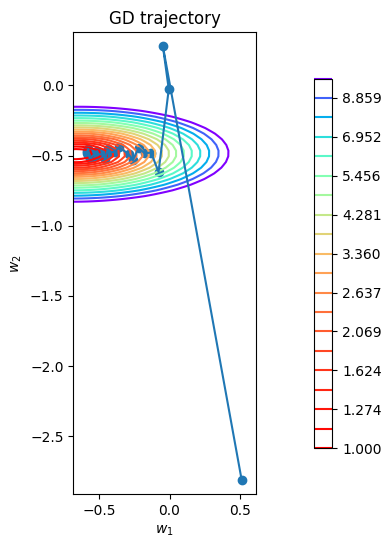

p = 0.5
final loss: 1.176183253632377


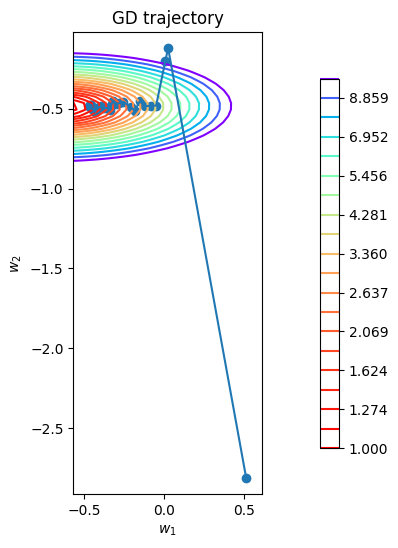

p = 0.7
final loss: 1.757066021118968


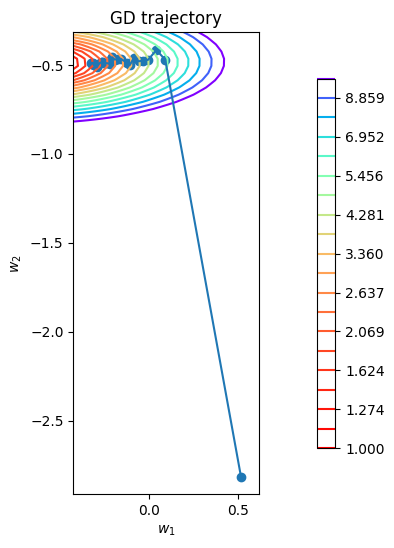

p = 1.0
final loss: 3.0729842116905086


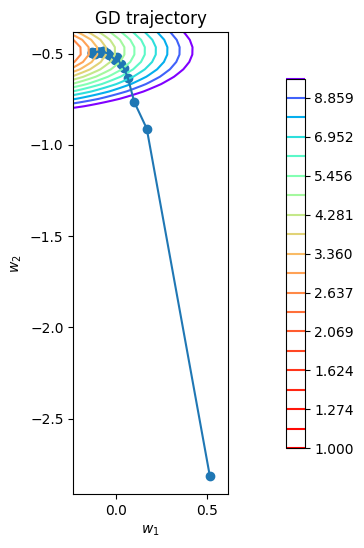

In [13]:
p_values = [0.1, 0.3, 0.5, 0.7, 1.0]

lr = 0.01
batch_size = 10

for p in p_values:
    np.random.seed(42)

    print(f"p = {p}")

    history = stochastic_gradient_descent(
        w_init=w_init,
        X=X,
        y=y,
        loss=loss,
        lr=lr,
        batch_size=batch_size,
        p=p,
        n_iterations=30
    )

    print("final loss:", loss.calc_loss(X, y, history[-1]))
    plot_gd(history, X, y, loss)

Параметр p управляет скоростью затухания шага. При маленьких значениях p шаг убывает медленно, алгоритм дольше делает большие обновления весов. Это позволяет быстрее перемещаться по поверхности функции потерь, но траектория получается более шумной, и около минимума может долго колебаться. При больших значениях p шаг убывает быстрее, спуск становится более плавным и стабильным. При этом есть риск, что шаг станет слишком маленьким слишком рано, и алгоритм будет сходиться медленнее. Можно сделать вывод, что маленькие p дают более агрессивное, резкое поведение, а большие p более стабильное.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

In [14]:
lr = 0.01
n_iterations = 30
batch_size = 10
p = 0.3  

np.random.seed(42)
gd_history = gradient_descent(
    w_init=w_init,
    X=X,
    y=y,
    loss=loss,
    lr=lr,
    n_iterations=n_iterations
)

np.random.seed(42)
sgd_history = stochastic_gradient_descent(
    w_init=w_init,
    X=X,
    y=y,
    loss=loss,
    lr=lr,
    batch_size=batch_size,
    p=p,
    n_iterations=n_iterations
)

In [15]:
gd_losses = [loss.calc_loss(X, y, w) for w in gd_history]
sgd_losses = [loss.calc_loss(X, y, w) for w in sgd_history]

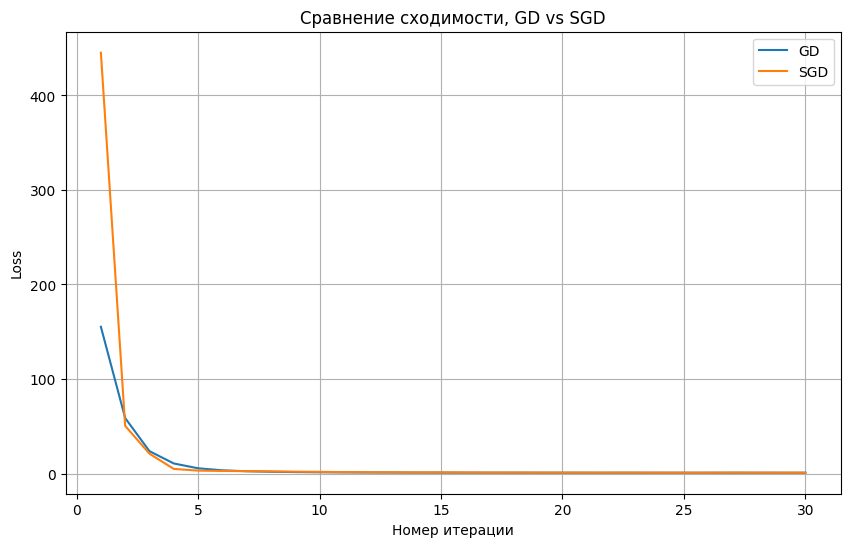

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, n_iterations + 1), gd_losses, label='GD')
plt.plot(range(1, n_iterations + 1), sgd_losses, label='SGD')

plt.xlabel('Номер итерации')
plt.ylabel('Loss')
plt.title('Сравнение сходимости, GD vs SGD')
plt.legend()
plt.grid()
plt.show()

In [17]:
print("Final GD loss:", gd_losses[-1])
print("Final SGD loss:", sgd_losses[-1])

Final GD loss: 0.8676452384843072
Final SGD loss: 0.9243760082677875


Обычный градиентный спуск сходится более плавно, потому что на каждой итерации использует всю выборку, тогда как стохастический ведёт себя более шумно, так как тут градиент считается только по случайному батчу в этой задаче из 10 объектов. На графике зависимости Loss от Номера итерации преимущество SGD не сказать, что сильно видно, но оно точно в том, что одна его итерация вычислительно дешевле обходится, так как один шаг SGD дешевле, чем шаг полного GD, особенно на больших датасетах, поэтому SGD будет выгоднее использовать по времени на больших выборках, хотя его траектория более шумная.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [18]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w0 = np.zeros(X.shape[1])

        w_trajectory = gradient_descent(w0, X, y, self.loss, self.lr)
        self.w = w_trajectory[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

        

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [19]:
linear_regression = LinearRegression(MSELoss()) 

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [20]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [21]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [23]:
df = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)

df = df[~df[26].isna()].reset_index(drop=True)

y = pd.to_numeric(df[26])

X = df.drop(columns=26).copy()

X.columns = X.columns.astype(str)

for col in X.columns:
    converted = pd.to_numeric(X[col], errors='coerce')
    if converted.notna().sum() == X[col].notna().sum():
        X[col] = converted


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

num_cols = X_train_raw.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train_raw.select_dtypes(exclude=['number']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (140, 74)
X_test shape: (61, 74)
y_train shape: (140,)
y_test shape: (61,)


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [24]:
linear_regression = LinearRegression(MSELoss())
linear_regression.fit(X_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [25]:
from sklearn.metrics import mean_squared_error

y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print("MSE на обучающей выборке:", mse_train)
print("MSE на тестовой выборке:", mse_test)

MSE на обучающей выборке: 1367326.6649561825
MSE на тестовой выборке: 8535816.803707369


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [26]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        w_reg = w.copy()
        w_reg[-1] = 0 

        return np.mean((X @ w - y) ** 2) + self.coef * np.sum(w_reg ** 2)
    
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        w_reg = w.copy()
        w_reg[-1] = 0  

        return 2 / X.shape[0] * X.T @ (X @ w - y) + 2 * self.coef * w_reg

    def calc_gradient(self, X, y, w):
        return self.calc_grad(X, y, w)
    
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [29]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

scaler_val = StandardScaler()
X_tr_scaled = scaler_val.fit_transform(X_tr)
X_val_scaled = scaler_val.transform(X_val)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)


def fit_and_score(loss, lr, X_fit, y_fit, X_eval, y_eval):
    model = LinearRegression(loss=loss, lr=lr)
    model.fit(X_fit, y_fit)

    if not np.isfinite(model.w).all():
        return model, np.inf, np.inf

    y_fit_pred = model.predict(X_fit)
    y_eval_pred = model.predict(X_eval)

    if not np.isfinite(y_fit_pred).all() or not np.isfinite(y_eval_pred).all():
        return model, np.inf, np.inf

    train_mse = mean_squared_error(y_fit, y_fit_pred)
    eval_mse = mean_squared_error(y_eval, y_eval_pred)

    return model, train_mse, eval_mse

lrs = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]

baseline_rows = []

for lr in lrs:
    model, train_mse, val_mse = fit_and_score(
        loss=MSELoss(),
        lr=lr,
        X_fit=X_tr_scaled, y_fit=y_tr,
        X_eval=X_val_scaled, y_eval=y_val
    )

    baseline_rows.append({
        "lr": lr,
        "train_mse": train_mse,
        "val_mse": val_mse
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("val_mse")
print("Подбор для MSELoss:")
display(baseline_df)

best_lr_baseline = baseline_df.iloc[0]["lr"]
print("Лучший lr для MSELoss:", best_lr_baseline)


coefs = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2]

l2_rows = []

for coef in coefs:
    for lr in lrs:
        model, train_mse, val_mse = fit_and_score(
            loss=MSEL2Loss(coef=coef),
            lr=lr,
            X_fit=X_tr_scaled, y_fit=y_tr,
            X_eval=X_val_scaled, y_eval=y_val
        )

        l2_rows.append({
            "coef": coef,
            "lr": lr,
            "train_mse": train_mse,
            "val_mse": val_mse
        })

l2_df = pd.DataFrame(l2_rows).sort_values("val_mse")
print("\nПодбор для MSEL2Loss:")
display(l2_df.head(10))

best_coef = l2_df.iloc[0]["coef"]
best_lr_l2 = l2_df.iloc[0]["lr"]

print("Лучший coef для MSEL2Loss:", best_coef)
print("Лучший lr для MSEL2Loss:", best_lr_l2)

baseline_model = LinearRegression(loss=MSELoss(), lr=best_lr_baseline)
baseline_model.fit(X_train_scaled, y_train)

y_train_pred_base = baseline_model.predict(X_train_scaled)
y_test_pred_base = baseline_model.predict(X_test_scaled)

train_mse_base = mean_squared_error(y_train, y_train_pred_base)
test_mse_base = mean_squared_error(y_test, y_test_pred_base)

l2_model = LinearRegression(loss=MSEL2Loss(coef=best_coef), lr=best_lr_l2)
l2_model.fit(X_train_scaled, y_train)

y_train_pred_l2 = l2_model.predict(X_train_scaled)
y_test_pred_l2 = l2_model.predict(X_test_scaled)

train_mse_l2 = mean_squared_error(y_train, y_train_pred_l2)
test_mse_l2 = mean_squared_error(y_test, y_test_pred_l2)


results = pd.DataFrame({
    "model": ["MSELoss", "MSEL2Loss"],
    "train_mse": [train_mse_base, train_mse_l2],
    "test_mse": [test_mse_base, test_mse_l2]
})

print("\nИтоговое сравнение:")
display(results)

Подбор для MSELoss:


,lr,train_mse,val_mse
1,0.00005,1.470774e+06,4.563470e+06
2,0.00010,1.313121e+06,5.274794e+06
4,0.00100,1.142054e+06,6.155362e+06
5,0.00500,1.140471e+06,6.189954e+06
3,0.00050,1.151991e+06,6.432645e+06
0,0.00001,5.073486e+06,9.525935e+06


Лучший lr для MSELoss: 5e-05

Подбор для MSEL2Loss:


,coef,lr,train_mse,val_mse
31,0.050000,0.00005,1.570909e+06,4.401395e+06
25,0.010000,0.00005,1.488711e+06,4.522289e+06
19,0.001000,0.00005,1.472506e+06,4.559109e+06
13,0.000100,0.00005,1.470946e+06,4.563031e+06
7,0.000010,0.00005,1.470791e+06,4.563426e+06
1,0.000001,0.00005,1.470775e+06,4.563465e+06
32,0.050000,0.00010,1.466386e+06,4.650002e+06
35,0.050000,0.00500,1.411244e+06,4.831062e+06
34,0.050000,0.00100,1.411244e+06,4.831063e+06
33,0.050000,0.00050,1.411355e+06,4.831540e+06


Лучший coef для MSEL2Loss: 0.05
Лучший lr для MSEL2Loss: 5e-05

Итоговое сравнение:


,model,train_mse,test_mse
0,MSELoss,1.656095e+06,7.947919e+06
1,MSEL2Loss,1.734138e+06,7.838238e+06


Для модели с L2-регуляризацией мной были подобраны гиперпараметры coef = 0.05 и lr = 5e-05 на валидационной выборке. А после обучения на полной обучающей выборке получилось, без регуляризации train MSE = 1.656095e+06, test MSE = 7.947919e+06. С L2-регуляризацией train MSE = 1.734138e+06, test MSE = 7.838238e+06. Как мы видим, при добавлении L2-регуляризации ошибка на обучающей выборке немного увеличилась, но ошибка на тестовой выборке уменьшилась. Таким образом, регуляризация действительно помогла снизить переобучение, и немного улучшилась обощающая способность модели.

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [38]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        errors = X @ w - y
        abs_errors = np.abs(errors)

        loss = np.where(
            abs_errors < self.eps,
            0.5 * errors ** 2,
            self.eps * (abs_errors - 0.5 * self.eps)
        )

        return np.mean(loss)


        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        errors = X @ w - y

        grad_phi = np.where(
            np.abs(errors) < self.eps,
            errors,
            self.eps * np.sign(errors)
        )

        return X.T @ grad_phi / X.shape[0]

    def calc_gradient(self, X, y, w):
        return self.calc_grad(X, y, w)

        # Вычислите значение вектора градиента при помощи X, y и w и верните его

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [ ]:
X_tr_h, X_val_h, y_tr_h, y_val_h = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

scaler_val_h = StandardScaler()
X_tr_h_scaled = scaler_val_h.fit_transform(X_tr_h)
X_val_h_scaled = scaler_val_h.transform(X_val_h)

scaler_full_h = StandardScaler()
X_train_h_scaled = scaler_full_h.fit_transform(X_train)
X_test_h_scaled = scaler_full_h.transform(X_test)


def fit_and_score_safe(loss, lr, X_fit, y_fit, X_eval, y_eval):
    model = LinearRegression(loss=loss, lr=lr)
    model.fit(X_fit, y_fit)

    if not np.isfinite(model.w).all():
        return model, np.inf, np.inf

    y_fit_pred = model.predict(X_fit)
    y_eval_pred = model.predict(X_eval)

    if not np.isfinite(y_fit_pred).all() or not np.isfinite(y_eval_pred).all():
        return model, np.inf, np.inf

    train_mse = mean_squared_error(y_fit, y_fit_pred)
    val_mse = mean_squared_error(y_eval, y_eval_pred)

    return model, train_mse, val_mse


lrs = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]

mse_rows_h = []

for lr in lrs:
    model, train_mse, val_mse = fit_and_score_safe(
        loss=MSELoss(),
        lr=lr,
        X_fit=X_tr_h_scaled, y_fit=y_tr_h,
        X_eval=X_val_h_scaled, y_eval=y_val_h
    )

    mse_rows_h.append({
        "lr": lr,
        "train_mse": train_mse,
        "val_mse": val_mse
    })

mse_df_h = pd.DataFrame(mse_rows_h).sort_values("val_mse")
print("Подбор для MSELoss:")
display(mse_df_h)

best_lr_mse_h = mse_df_h.iloc[0]["lr"]
print("Лучший lr для MSELoss:", best_lr_mse_h)


mse_val_model = LinearRegression(loss=MSELoss(), lr=best_lr_mse_h)
mse_val_model.fit(X_tr_h_scaled, y_tr_h)

val_abs_err = np.abs(y_val_h - mse_val_model.predict(X_val_h_scaled))

q50, q75, q90, q95 = np.quantile(val_abs_err, [0.50, 0.75, 0.90, 0.95])

raw_eps = [
    0.25 * q50,
    0.50 * q50,
    q50,
    q75,
    q90,
    q95,
    1.50 * q95
]

eps_values = sorted(set(float(max(1, int(round(v)))) for v in raw_eps))

print("\nКандидаты eps для HuberLoss:", eps_values)


huber_rows = []

for eps in eps_values:
    for lr in lrs:
        model, train_mse, val_mse = fit_and_score_safe(
            loss=HuberLoss(eps=eps),
            lr=lr,
            X_fit=X_tr_h_scaled, y_fit=y_tr_h,
            X_eval=X_val_h_scaled, y_eval=y_val_h
        )

        huber_rows.append({
            "eps": eps,
            "lr": lr,
            "train_mse": train_mse,
            "val_mse": val_mse
        })

huber_df = pd.DataFrame(huber_rows).sort_values("val_mse")
print("\nПодбор для HuberLoss:")
display(huber_df.head(10))

best_eps = huber_df.iloc[0]["eps"]
best_lr_huber = huber_df.iloc[0]["lr"]

print("Лучший eps для HuberLoss:", best_eps)
print("Лучший lr для HuberLoss:", best_lr_huber)


mse_final_model = LinearRegression(loss=MSELoss(), lr=best_lr_mse_h)
mse_final_model.fit(X_train_h_scaled, y_train)

y_train_pred_mse = mse_final_model.predict(X_train_h_scaled)
y_test_pred_mse = mse_final_model.predict(X_test_h_scaled)

train_mse_mse = mean_squared_error(y_train, y_train_pred_mse)
test_mse_mse = mean_squared_error(y_test, y_test_pred_mse)

huber_final_model = LinearRegression(loss=HuberLoss(eps=best_eps), lr=best_lr_huber)
huber_final_model.fit(X_train_h_scaled, y_train)

y_train_pred_huber = huber_final_model.predict(X_train_h_scaled)
y_test_pred_huber = huber_final_model.predict(X_test_h_scaled)

train_mse_huber = mean_squared_error(y_train, y_train_pred_huber)
test_mse_huber = mean_squared_error(y_test, y_test_pred_huber)

results_huber = pd.DataFrame({
    "model": ["MSELoss", "HuberLoss"],
    "train_mse": [train_mse_mse, train_mse_huber],
    "test_mse": [test_mse_mse, test_mse_huber]
})

print("\nИтоговое сравнение:")
display(results_huber)

Подбор для MSELoss:


,lr,train_mse,val_mse
3,0.000050,1.470774e+06,4.563470e+06
4,0.000100,1.313121e+06,5.274794e+06
6,0.001000,1.142054e+06,6.155362e+06
7,0.005000,1.140471e+06,6.189954e+06
5,0.000500,1.151991e+06,6.432645e+06
2,0.000010,5.073486e+06,9.525935e+06
1,0.000005,2.469473e+07,3.050346e+07
0,0.000001,1.158355e+08,1.163833e+08


Лучший lr для MSELoss: 5e-05

Кандидаты eps для HuberLoss: [328.0, 657.0, 1313.0, 2252.0, 3208.0, 4737.0, 7105.0]

Подбор для HuberLoss:


,eps,lr,train_mse,val_mse
28,2252.0,0.00010,2.020450e+06,4.098022e+06
36,3208.0,0.00010,1.667721e+06,4.202812e+06
13,657.0,0.00050,1.867030e+06,4.206408e+06
44,4737.0,0.00010,1.543740e+06,4.370721e+06
52,7105.0,0.00010,1.503714e+06,4.455877e+06
21,1313.0,0.00050,1.494272e+06,4.543102e+06
6,328.0,0.00100,1.955968e+06,4.555533e+06
51,7105.0,0.00005,1.800341e+06,4.594732e+06
43,4737.0,0.00005,2.066249e+06,4.698742e+06
14,657.0,0.00100,1.637176e+06,4.750077e+06


Лучший eps для HuberLoss: 2252.0
Лучший lr для HuberLoss: 0.0001

Итоговое сравнение:


,model,train_mse,test_mse
0,MSELoss,1.656095e+06,7.947919e+06
1,HuberLoss,2.101328e+06,7.788356e+06


Для модели с HuberLoss по валидационной выборке я подобрала гиперпараметры eps = 2252 и lr = 0.0001.  
После обучения на полной обучающей выборке получилось для MSELoss на train MSE = 1.656095e+06, test MSE = 7.947919e+06, а для HuberLoss на train MSE = 2.101328e+06, test MSE = 7.788356e+06. Как можно заметить, модель с HuberLoss показала немного худший результат на обучающей выборке, но лучше результат на тестовой выборке. Модель с HuberLoss действительно помогло уменьшить влияние выбросов и немного улучшить качество модели на новых данных.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

![мем](https://i.ytimg.com/vi/M2vKkHfz5jE/maxresdefault.jpg)

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

Траектория градиентного спуска


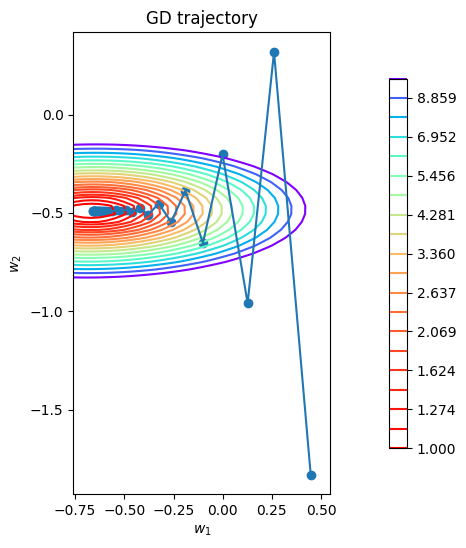

Траектория имитации отжига


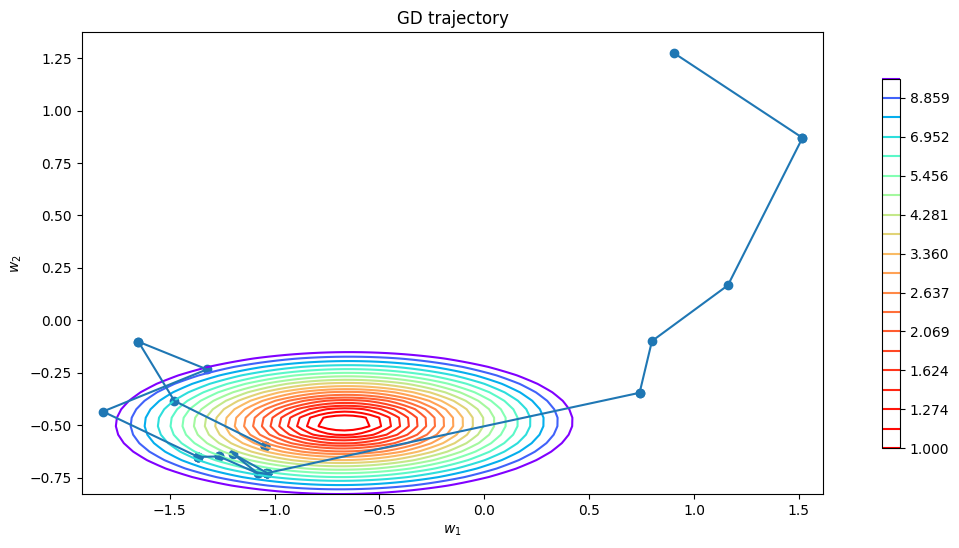

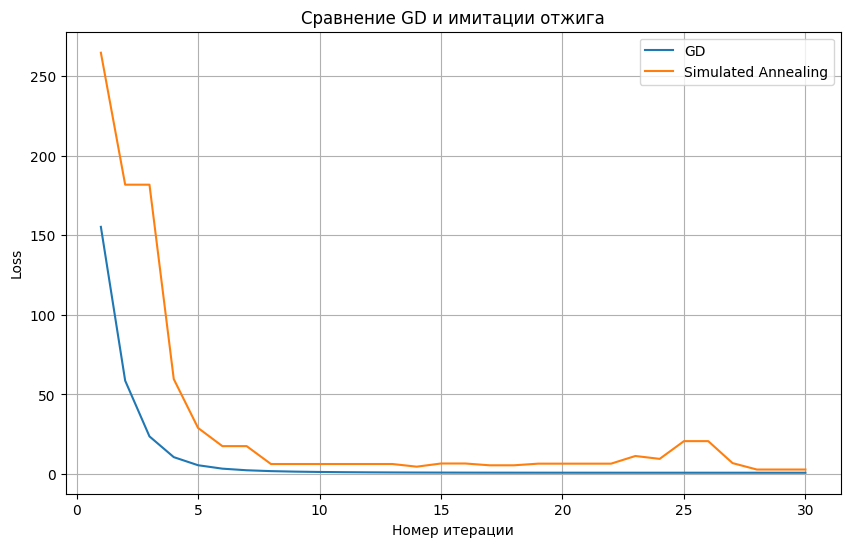

Final GD loss: 0.8676452384843072
Final SA loss: 2.8726994015670577


In [40]:
def simulated_annealing(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    t0: float,
    alpha: float,
    step_scale: float,
    df: int = 3,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    
    w = w_init.copy().astype(float)
    history = []

    current_loss = loss.calc_loss(X, y, w)
    T = t0

    for _ in range(n_iterations):
        proposal_scale = step_scale * np.sqrt(T)

        w_new = w + proposal_scale * np.random.standard_t(df=df, size=w.shape)
        new_loss = loss.calc_loss(X, y, w_new)

        delta = new_loss - current_loss

        if delta < 0 or np.random.rand() < np.exp(-delta / max(T, 1e-12)):
            w = w_new
            current_loss = new_loss

        history.append(w.copy())
        T *= alpha

    return history


np.random.seed(1337)

n_features = 2
n_objects = 300

w_true = np.random.normal(size=(n_features,))

X_bonus = np.random.uniform(-5, 5, (n_objects, n_features))
X_bonus *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y_bonus = X_bonus.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init_bonus = np.random.uniform(-2, 2, (n_features))

bonus_loss = MSELoss()
n_iterations = 30

gd_history = gradient_descent(
    w_init=w_init_bonus,
    X=X_bonus,
    y=y_bonus,
    loss=bonus_loss,
    lr=0.01,
    n_iterations=n_iterations
)

np.random.seed(42)
sa_history = simulated_annealing(
    w_init=w_init_bonus,
    X=X_bonus,
    y=y_bonus,
    loss=bonus_loss,
    t0=10.0,
    alpha=0.98,
    step_scale=0.15,
    df=3,
    n_iterations=n_iterations
)

print("Траектория градиентного спуска")
plot_gd(gd_history, X_bonus, y_bonus, bonus_loss)

print("Траектория имитации отжига")
plot_gd(sa_history, X_bonus, y_bonus, bonus_loss)

gd_losses = [bonus_loss.calc_loss(X_bonus, y_bonus, w) for w in gd_history]
sa_losses = [bonus_loss.calc_loss(X_bonus, y_bonus, w) for w in sa_history]

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_iterations + 1), gd_losses, label='GD')
plt.plot(range(1, n_iterations + 1), sa_losses, label='Simulated Annealing')
plt.xlabel('Номер итерации')
plt.ylabel('Loss')
plt.title('Сравнение GD и имитации отжига')
plt.legend()
plt.grid()
plt.show()

print("Final GD loss:", gd_losses[-1])
print("Final SA loss:", sa_losses[-1])

По траектории видно, что градиентный спуск движется к минимуму более плавно и стабильно. loss быстро убывает и дальше почти монотонно выходит на минимум. В то же время, имитация отжига ведёт себя более хаотично. На некоторых итерациях значение loss увеличивается, потому что алгоритм иногда принимает даже ухудшающие переходы. Это делает сходимость менее стабильной. Как видно, по финальному значению функции потерь градиентный спуск оказался лучше = 0.8676, он дал и более аккуратную траекторию, и меньший итоговый лосс. Более того, для линейной регрессии с MSE функция потерь выпуклая, и градиентный спуск на такой задаче работает особенно хорошо. 